In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load dataset
df = pd.read_csv('pjm_hourly_est.csv')

# Convert Datetime and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Feature Engineering from Datetime
df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month
df['Year'] = df['Datetime'].dt.year
df['DayOfYear'] = df['Datetime'].dt.dayofyear

# We will focus our target analysis on 'PJM_Load' (the total system load)
# Drop rows where target variable PJM_Load is missing
df = df.dropna(subset=['PJM_Load'])

In [56]:
# Setting style for professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

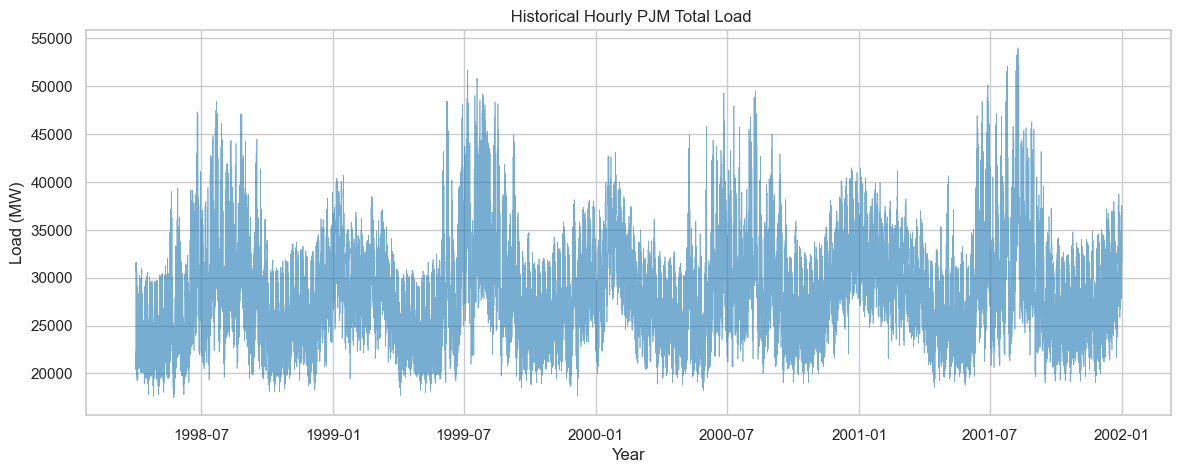

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(df['Datetime'], df['PJM_Load'], color='tab:blue', alpha=0.6, linewidth=0.5)
plt.title(" Historical Hourly PJM Total Load")
plt.xlabel("Year")
plt.ylabel("Load (MW)")
plt.show()

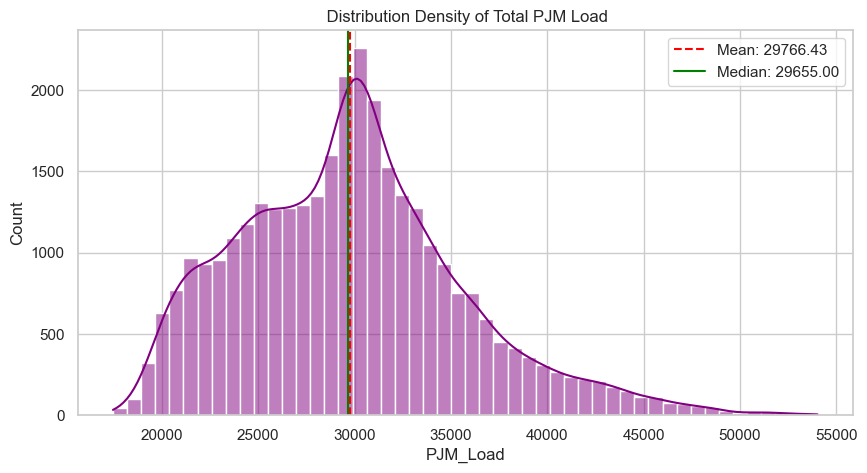

In [61]:
plt.figure(figsize=(10, 5))
sns.histplot(df['PJM_Load'], kde=True, color='purple', bins=50)
plt.axvline(df['PJM_Load'].mean(), color='red', linestyle='--', label=f"Mean: {df['PJM_Load'].mean():.2f}")
plt.axvline(df['PJM_Load'].median(), color='green', linestyle='-', label=f"Median: {df['PJM_Load'].median():.2f}")
plt.title(" Distribution Density of Total PJM Load")
plt.legend()
plt.show()

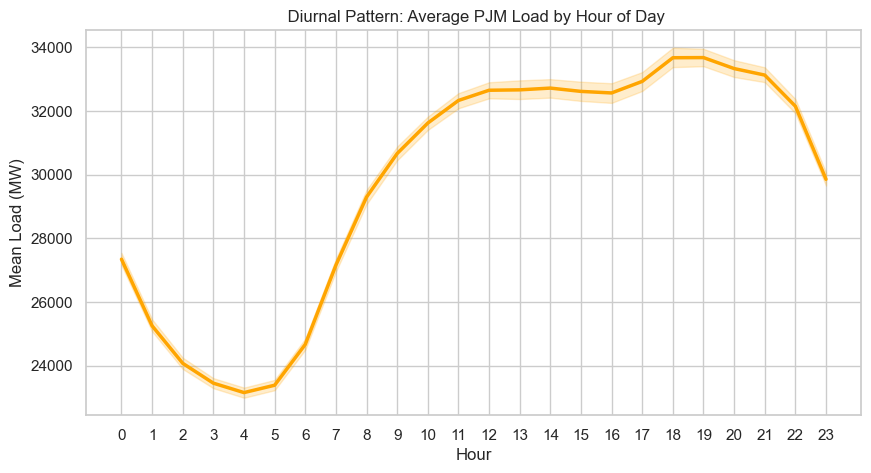

In [62]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Hour', y='PJM_Load', estimator='mean', color='orange', linewidth=2.5)
plt.title(" Diurnal Pattern: Average PJM Load by Hour of Day")
plt.xticks(range(0, 24))
plt.ylabel("Mean Load (MW)")
plt.show()

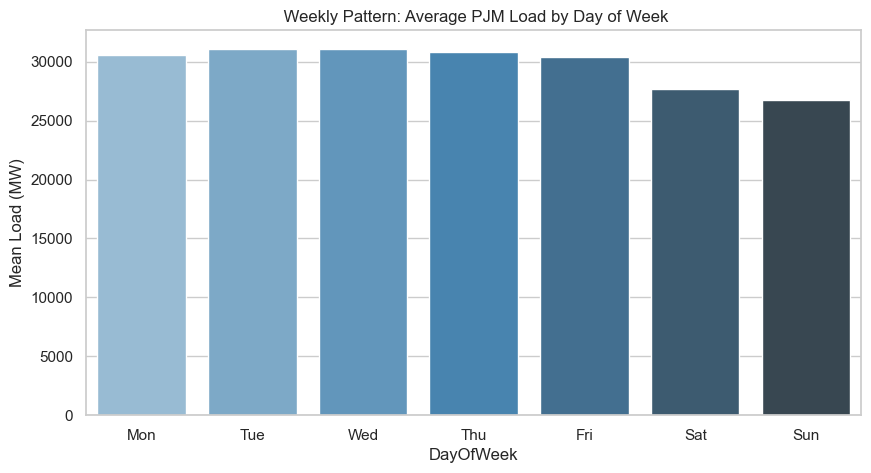

In [63]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='DayOfWeek', y='PJM_Load', palette='Blues_d', ci=None)
plt.title(" Weekly Pattern: Average PJM Load by Day of Week")
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.ylabel("Mean Load (MW)")
plt.show()

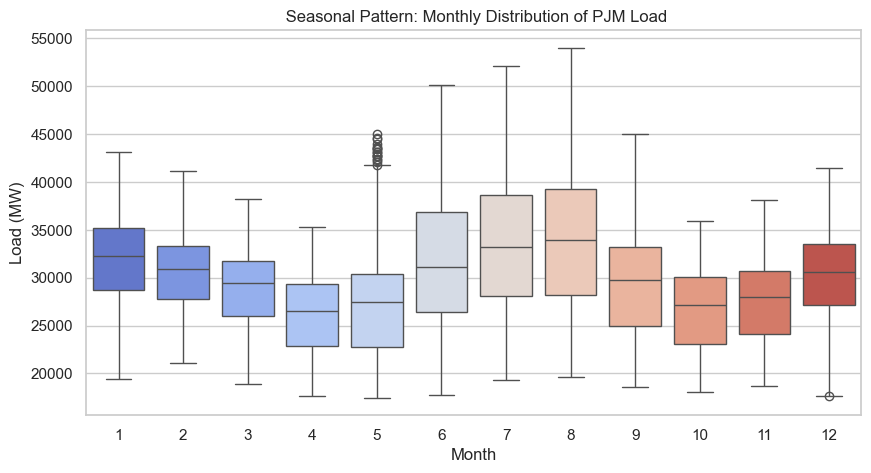

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Month', y='PJM_Load', palette='coolwarm')
plt.title(" Seasonal Pattern: Monthly Distribution of PJM Load")
plt.ylabel("Load (MW)")
plt.show()

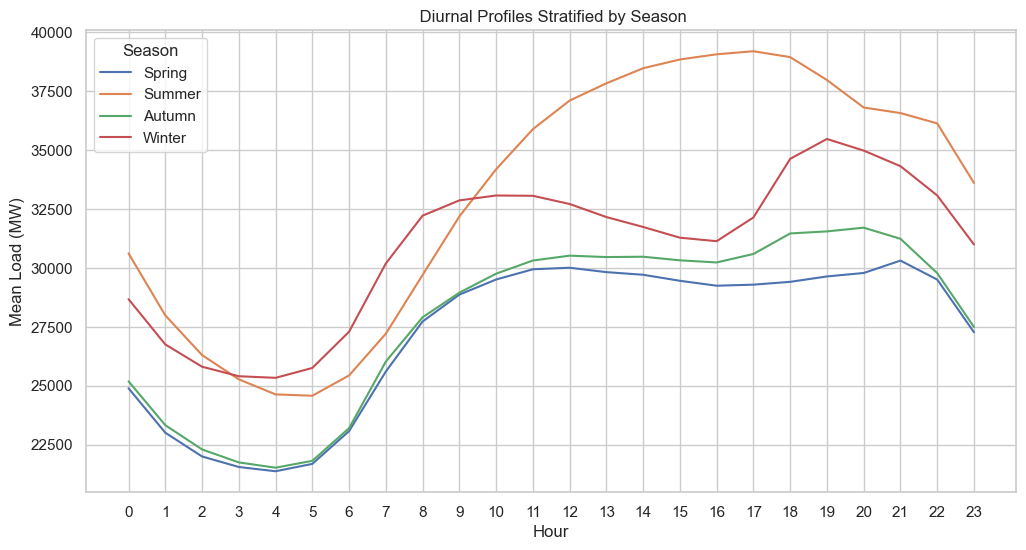

In [65]:
df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter',
                                3:'Spring', 4:'Spring', 5:'Spring',
                                6:'Summer', 7:'Summer', 8:'Summer',
                                9:'Autumn', 10:'Autumn', 11:'Autumn'})

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Hour', y='PJM_Load', hue='Season', estimator='mean', ci=None)
plt.title(" Diurnal Profiles Stratified by Season")
plt.xticks(range(0, 24))
plt.ylabel("Mean Load (MW)")
plt.show()

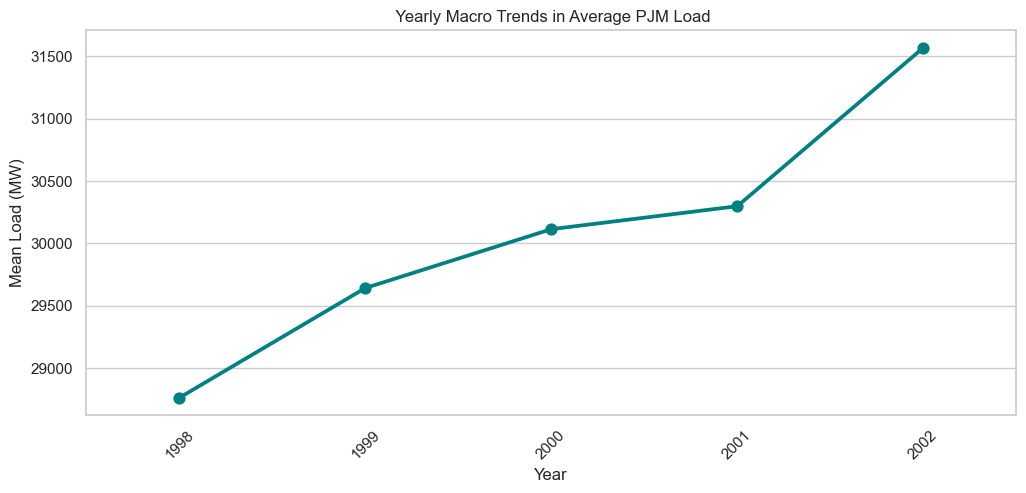

In [67]:
plt.figure(figsize=(12, 5))
sns.pointplot(data=df, x='Year', y='PJM_Load', estimator='mean', color='teal', ci=None)
plt.title(" Yearly Macro Trends in Average PJM Load")
plt.xticks(rotation=45)
plt.ylabel("Mean Load (MW)")
plt.show()

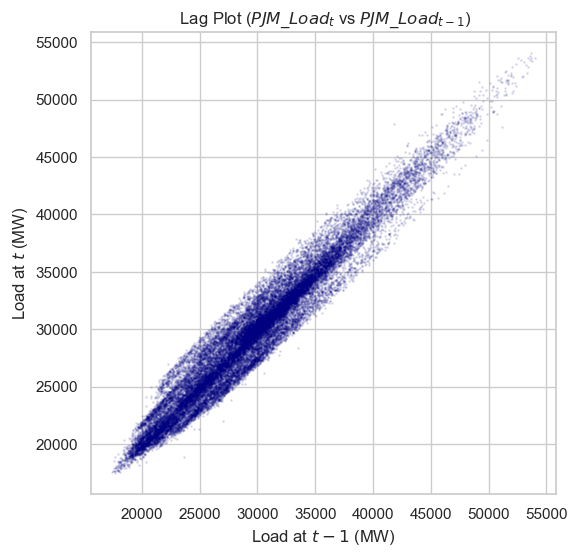

In [68]:
df['Lag_1h'] = df['PJM_Load'].shift(1)

plt.figure(figsize=(6, 6))
plt.scatter(df['Lag_1h'], df['PJM_Load'], alpha=0.1, color='navy', s=1)
plt.title(" Lag Plot ($PJM\_Load_{t}$ vs $PJM\_Load_{t-1}$)")
plt.xlabel("Load at $t-1$ (MW)")
plt.ylabel("Load at $t$ (MW)")
plt.show()

In [69]:
# Building time-series lag features for prediction
df['Lag_1'] = df['PJM_Load'].shift(1)
df['Lag_2'] = df['PJM_Load'].shift(2)
df['Lag_24'] = df['PJM_Load'].shift(24)

# Drop rows with NaN resulting from shifts
knn_data = df[['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'Lag_1', 'Lag_2', 'Lag_24', 'PJM_Load']].dropna()

# Separate features (X) and target (y)
X = knn_data[['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'Lag_1', 'Lag_2', 'Lag_24']]
y = knn_data['PJM_Load']

# Train-Test Split (Chronological split is ideal for time-series, but for standard kNN evaluation we will use 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Feature Scaling (Crucial for distance-based algorithms like kNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
# Initialize and fit the model
knn = KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- kNN Model Performance Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"Mean Absolute Error (MAE):     {mae:.2f} MW")
print(f"R-squared Score ($R^2$):         {r2:.4f}")

--- kNN Model Performance Evaluation ---
Root Mean Squared Error (RMSE): 660.87 MW
Mean Absolute Error (MAE):     482.30 MW
R-squared Score ($R^2$):         0.9873


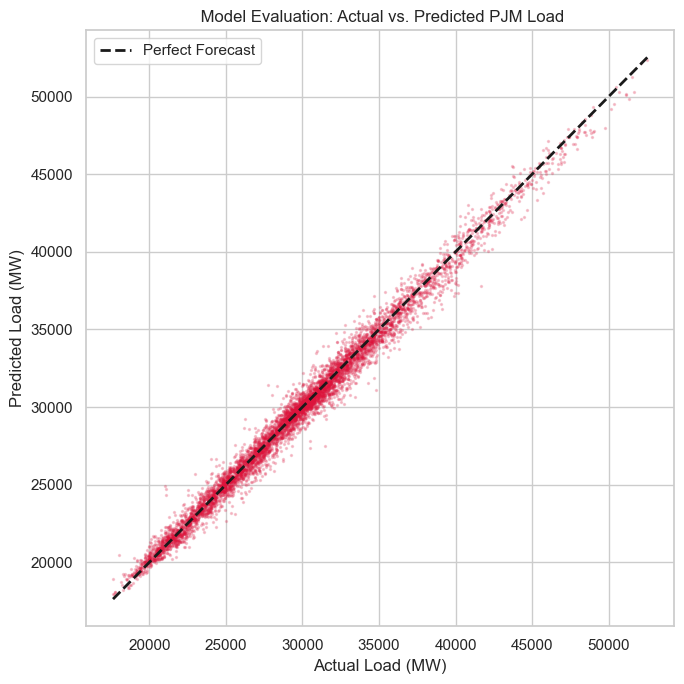

In [72]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.2, color='crimson', s=2)
# Perfect prediction reference line
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Forecast')

plt.title(" Model Evaluation: Actual vs. Predicted PJM Load")
plt.xlabel("Actual Load (MW)")
plt.ylabel("Predicted Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
df

,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load,Hour,DayOfWeek,Month,Year,DayOfYear,Season,Lag_1h,Lag_1,Lag_2,Lag_24
0,1998-04-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22259.0,1,2,4,1998,91,Spring,NaN,NaN,NaN,NaN
1,1998-04-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21244.0,2,2,4,1998,91,Spring,22259.0,22259.0,NaN,NaN
2,1998-04-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20651.0,3,2,4,1998,91,Spring,21244.0,21244.0,22259.0,NaN
3,1998-04-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20421.0,4,2,4,1998,91,Spring,20651.0,20651.0,21244.0,NaN
4,1998-04-01 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20713.0,5,2,4,1998,91,Spring,20421.0,20421.0,20651.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32891,2001-12-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36392.0,20,0,12,2001,365,Winter,37570.0,37570.0,37568.0,36353.0
32892,2001-12-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35082.0,21,0,12,2001,365,Winter,36392.0,36392.0,37570.0,35974.0
32893,2001-12-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33890.0,22,0,12,2001,365,Winter,35082.0,35082.0,36392.0,34979.0
32894,2001-12-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32590.0,23,0,12,2001,365,Winter,33890.0,33890.0,35082.0,33331.0


In [74]:
df.isna().sum()

Datetime         0
AEP          32896
COMED        32896
DAYTON       32896
DEOK         32896
DOM          32896
DUQ          32896
EKPC         32896
FE           32896
NI           32896
PJME         32896
PJMW         32896
PJM_Load         0
Hour             0
DayOfWeek        0
Month            0
Year             0
DayOfYear        0
Season           0
Lag_1h           1
Lag_1            1
Lag_2            2
Lag_24          24
dtype: int64

In [75]:
df.shape

(32896, 23)